In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb

# Helps make comparisons more reproducible
keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


Import the packages. The random seed is added because it helps prevent differences between experiments from being caused only by different random starting weights.

In [69]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

print("Training reviews:", len(train_data))
print("Test reviews:", len(test_data))

print("\nFirst review:")
print(train_data[0][:20])

print("\nFirst label:")
print(train_labels[0])

Training reviews: 25000
Test reviews: 25000

First review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]

First label:
1


Load the IMDB data already included with Keras. The data uses the top 10,000 most frequent words. The reviews have already been converted to sequences of integers, which explains the first review results of 1, 14, 22 and so on.

In [70]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros(
        (len(sequences), dimension),
        dtype="float32"
    )

    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0

    return results


x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (25000, 10000)
x_test shape: (25000, 10000)
y_train shape: (25000,)
y_test shape: (25000,)


Convert the reviews to tensors. The integer sequences cannot be fed directly into this dense network. They convert each review into a 10,000-element vector of 0s and 1s.

In [71]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

print("Partial training set:", partial_x_train.shape)
print("Validation set:", x_val.shape)

Partial training set: (15000, 10000)
Validation set: (10000, 10000)


Create the Validation set

In [72]:
baseline_model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

This is the model from the lecture, used as the baseline. It includes two hidden Dense layers, 16 nodes in each, relu for both hidden layers, one output node, and sigmoid output activation.

In [73]:
baseline_history = baseline_model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7762 - loss: 0.5288 - val_accuracy: 0.8646 - val_loss: 0.3964
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8901 - loss: 0.3252 - val_accuracy: 0.8843 - val_loss: 0.3092
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9209 - loss: 0.2385 - val_accuracy: 0.8825 - val_loss: 0.2947
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9347 - loss: 0.1967 - val_accuracy: 0.8877 - val_loss: 0.2767
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9442 - loss: 0.1659 - val_accuracy: 0.8856 - val_loss: 0.2789
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9549 - loss: 0.1402 - val_accuracy: 0.8848 - val_loss: 0.2874
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9628 - loss: 0.1208 - val_accuracy: 0.8839 - val_loss: 0.2968
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9698 - loss: 0.1022 - val_accuracy: 0.8815 - v

Train the baseline for 20 epochs and evaluate the performance against the validation set.

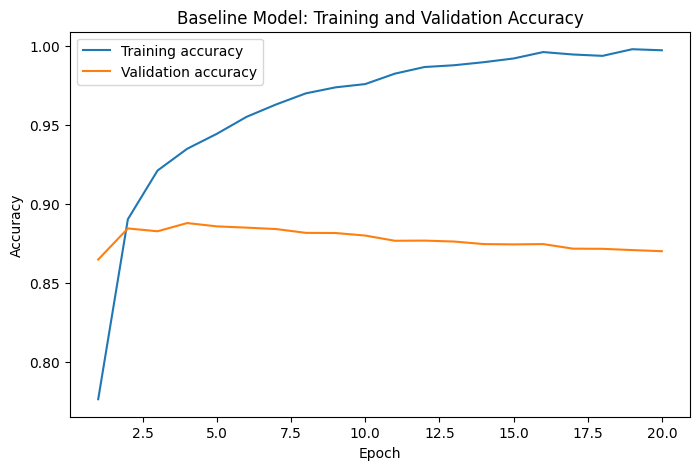

In [74]:
history_dict = baseline_history.history

epochs = range(1, len(history_dict["accuracy"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_dict["accuracy"],
    label="Training accuracy"
)

plt.plot(
    epochs,
    history_dict["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Model: Training and Validation Accuracy")
plt.legend()
plt.show()

Chart created for validation accuracy

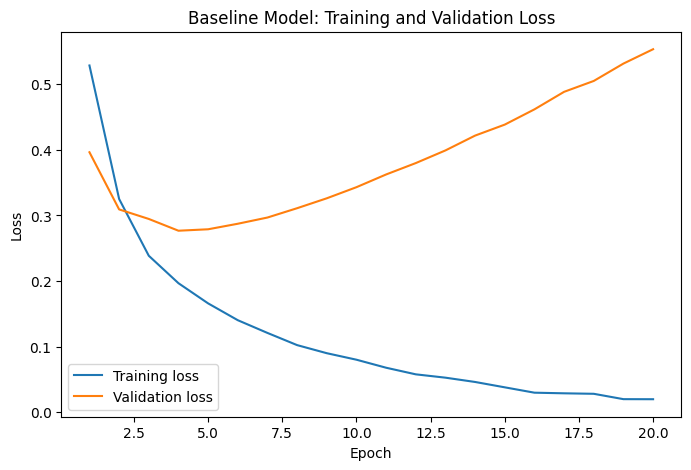

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_dict["loss"],
    label="Training loss"
)

plt.plot(
    epochs,
    history_dict["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Model: Training and Validation Loss")
plt.legend()
plt.show()

Plot the loss because training accuracy continues to improve while validation performance eventually deteriorates, indicating overtraining/overfitting.

In [76]:
baseline_best_epoch = (
    np.argmax(baseline_history.history["val_accuracy"]) + 1
)

baseline_best_val_accuracy = max(
    baseline_history.history["val_accuracy"]
)

print("Best epoch:", baseline_best_epoch)
print(
    "Best validation accuracy:",
    round(baseline_best_val_accuracy, 4)
)

Best epoch: 4
Best validation accuracy: 0.8877


Determine the best validation epoch.

In [77]:
def build_model(
    hidden_layers=2,
    units=16,
    activation="relu",
    loss="binary_crossentropy",
    dropout_rate=None
):

    model = keras.Sequential()

    for i in range(hidden_layers):
        model.add(
            layers.Dense(
                units,
                activation=activation
            )
        )

        if dropout_rate is not None:
            model.add(
                layers.Dropout(dropout_rate)
            )

    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    model.compile(
        optimizer="rmsprop",
        loss=loss,
        metrics=["accuracy"]
    )

    return model

Create a reusable model function. This is one function that allows me to change number of hidden layers, number of units, activation loss, and dropout

In [78]:
def run_experiment(
    name,
    hidden_layers=2,
    units=16,
    activation="relu",
    loss="binary_crossentropy",
    dropout_rate=None
):

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    # Reset seed to make model comparisons more consistent
    keras.utils.set_random_seed(42)

    model = build_model(
        hidden_layers=hidden_layers,
        units=units,
        activation=activation,
        loss=loss,
        dropout_rate=dropout_rate
    )

    history = model.fit(
        partial_x_train,
        partial_y_train,
        epochs=20,
        batch_size=512,
        validation_data=(x_val, y_val),
        verbose=0
    )

    val_accuracies = history.history["val_accuracy"]

    best_epoch = np.argmax(val_accuracies) + 1
    best_val_accuracy = max(val_accuracies)

    # Retrain fresh model using all original training data
    keras.utils.set_random_seed(42)

    final_model = build_model(
        hidden_layers=hidden_layers,
        units=units,
        activation=activation,
        loss=loss,
        dropout_rate=dropout_rate
    )

    final_model.fit(
        x_train,
        y_train,
        epochs=best_epoch,
        batch_size=512,
        verbose=0
    )

    test_loss, test_accuracy = final_model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    print("Best epoch:", best_epoch)
    print("Best validation accuracy:", round(best_val_accuracy, 4))
    print("Test accuracy:", round(test_accuracy, 4))

    return {
        "Model": name,
        "Hidden Layers": hidden_layers,
        "Units": units,
        "Activation": activation,
        "Loss": loss,
        "Dropout": dropout_rate,
        "Best Epoch": best_epoch,
        "Validation Accuracy": best_val_accuracy,
        "Test Accuracy": test_accuracy
    }

Function used to run 1 experiment. This function will create the model, train it for 20 epochs, find the best validation epoch, retrain a fresh version, evaluate it against the test set, and save the results.

In [79]:
results = []

results.append(
    run_experiment(
        name="Baseline: 2 layers, 16 units, ReLU, BCE",
        hidden_layers=2,
        units=16,
        activation="relu",
        loss="binary_crossentropy"
    )
)


Baseline: 2 layers, 16 units, ReLU, BCE
Best epoch: 4
Best validation accuracy: 0.8877
Test accuracy: 0.8836


Run the baseline through the comparison function.

In [80]:
results.append(
    run_experiment(
        name="1 hidden layer, 16 units",
        hidden_layers=1,
        units=16,
        activation="relu",
        loss="binary_crossentropy"
    )
)

results.append(
    run_experiment(
        name="3 hidden layers, 16 units",
        hidden_layers=3,
        units=16,
        activation="relu",
        loss="binary_crossentropy"
    )
)


1 hidden layer, 16 units
Best epoch: 5
Best validation accuracy: 0.8877
Test accuracy: 0.8877

3 hidden layers, 16 units
Best epoch: 4
Best validation accuracy: 0.8887
Test accuracy: 0.8844


Number of Hidden Layers: The baseline model with two hidden layers reached its best validation accuracy of 0.8877 at epoch 4. Reducing the network to one hidden layer resulted in the same best validation accuracy of 0.8877, although it required 5 epochs to reach that value. Increasing the network to three hidden layers produced a slightly higher validation accuracy of 0.8887 at epoch 4. Its test accuracy was 0.8844. Overall, changing the number of hidden layers had only a small effect on validation performance. Three hidden layers produced the highest validation accuracy among these models, but the improvement over the baseline was only 0.0010, suggesting that additional depth provided little practical benefit.

In [81]:
results.append(
    run_experiment(
        name="2 layers, 8 units",
        hidden_layers=2,
        units=8,
        activation="relu",
        loss="binary_crossentropy"
    )
)

results.append(
    run_experiment(
        name="2 layers, 32 units",
        hidden_layers=2,
        units=32,
        activation="relu",
        loss="binary_crossentropy"
    )
)

results.append(
    run_experiment(
        name="2 layers, 64 units",
        hidden_layers=2,
        units=64,
        activation="relu",
        loss="binary_crossentropy"
    )
)


2 layers, 8 units
Best epoch: 5
Best validation accuracy: 0.8877
Test accuracy: 0.889

2 layers, 32 units
Best epoch: 3
Best validation accuracy: 0.8901
Test accuracy: 0.883

2 layers, 64 units
Best epoch: 3
Best validation accuracy: 0.8903
Test accuracy: 0.8866


Number of Hidden Units: Increasing the number of units improved validation accuracy slightly. The model with 8 units reached a best validation accuracy of 0.8877 at epoch 5, while the models with 32 and 64 units both reached their best performance earlier, at epoch 3, with validation accuracies of 0.8901 and 0.8903, respectively. The 64-unit model produced the highest validation accuracy, although its advantage over 32 units was very small. Test accuracy did not follow the same pattern: the 8-unit model had the highest test accuracy at 0.8890, compared with 0.8830 for 32 units and 0.8866 for 64 units. This suggests that increasing the number of hidden units allowed the model to fit the validation data slightly better and reach its best performance sooner, but additional model capacity did not consistently improve performance on the unseen test data.

In [82]:
results.append(
    run_experiment(
        name="2x16 ReLU with MSE",
        hidden_layers=2,
        units=16,
        activation="relu",
        loss="mse"
    )
)


2x16 ReLU with MSE
Best epoch: 4
Best validation accuracy: 0.8875
Test accuracy: 0.8833


Loss Function: The original 2×16 ReLU model using binary crossentropy reached its best validation accuracy of 0.8877 at epoch 4. When the loss function was changed to mean squared error (MSE), the best epoch remained 4 and validation accuracy decreased slightly to 0.8875. The MSE model achieved a test accuracy of 0.8833. The difference in validation accuracy was very small, but MSE did not improve performance over binary crossentropy for this binary classification problem.

In [83]:
results.append(
    run_experiment(
        name="2x16 Tanh with BCE",
        hidden_layers=2,
        units=16,
        activation="tanh",
        loss="binary_crossentropy"
    )
)


2x16 Tanh with BCE
Best epoch: 4
Best validation accuracy: 0.8873
Test accuracy: 0.8774


Activation Function: The original 2×16 model using ReLU reached its best validation accuracy of 0.8877 at epoch 4. Replacing ReLU with tanh did not change the best epoch, which remained 4, but validation accuracy decreased slightly to 0.8873. The tanh model achieved a test accuracy of 0.8774. Therefore, tanh did not improve validation performance and produced a noticeably lower test accuracy than the ReLU baseline.

In [84]:
results.append(
    run_experiment(
        name="2x32 ReLU with Dropout 0.5",
        hidden_layers=2,
        units=32,
        activation="relu",
        loss="binary_crossentropy",
        dropout_rate=0.5
    )
)


2x32 ReLU with Dropout 0.5
Best epoch: 6
Best validation accuracy: 0.889
Test accuracy: 0.8786


In [85]:
results.append(
    run_experiment(
        name="2x64 ReLU with Dropout 0.2",
        hidden_layers=2,
        units=64,
        activation="relu",
        loss="binary_crossentropy",
        dropout_rate=0.2
    )
)

results.append(
    run_experiment(
        name="2x64 ReLU with Dropout 0.3",
        hidden_layers=2,
        units=64,
        activation="relu",
        loss="binary_crossentropy",
        dropout_rate=0.3
    )
)


2x64 ReLU with Dropout 0.2
Best epoch: 4
Best validation accuracy: 0.8875
Test accuracy: 0.8808

2x64 ReLU with Dropout 0.3
Best epoch: 4
Best validation accuracy: 0.8897
Test accuracy: 0.8851


Dropout / Regularization: I tested dropout as a regularization technique to determine whether it would improve validation performance. For the 2×64 ReLU binary-crossentropy model, a dropout rate of 0.2 produced a best validation accuracy of 0.8875 at epoch 4 and a test accuracy of 0.8808, while a dropout rate of 0.3 produced a best validation accuracy of 0.8897 at epoch 4 and a test accuracy of 0.8851. I also tested 0.5 dropout on the 2×32 ReLU model, which produced a validation accuracy of 0.8890 at epoch 6 and a test accuracy of 0.8786. Although dropout 0.3 performed better than the other dropout settings, none of the dropout models outperformed the best non-dropout model, which was the 2×64 ReLU model with a validation accuracy of 0.8903. Therefore, dropout did not improve performance for this IMDB classification problem.

In [86]:
# Convert all experiment results to a DataFrame
results_df = pd.DataFrame(results)

# Remove duplicate configurations if a model was run more than once
results_df = results_df.drop_duplicates(
    subset=[
        "Hidden Layers",
        "Units",
        "Activation",
        "Loss",
        "Dropout"
    ],
    keep="last"
)

# Sort by validation accuracy
results_df = results_df.sort_values(
    by="Validation Accuracy",
    ascending=False
).reset_index(drop=True)

# Add rank
results_df.insert(
    0,
    "Rank",
    range(1, len(results_df) + 1)
)

display(results_df)

,Rank,Model,Hidden Layers,Units,Activation,Loss,Dropout,Best Epoch,Validation Accuracy,Test Accuracy
0,1,"2 layers, 64 units",2,64,relu,binary_crossentropy,NaN,3,0.8903,0.88660
1,2,"2 layers, 32 units",2,32,relu,binary_crossentropy,NaN,3,0.8901,0.88304
2,3,2x64 ReLU with Dropout 0.3,2,64,relu,binary_crossentropy,0.3,4,0.8897,0.88512
3,4,2x32 ReLU with Dropout 0.5,2,32,relu,binary_crossentropy,0.5,6,0.8890,0.87864
4,5,"3 hidden layers, 16 units",3,16,relu,binary_crossentropy,NaN,4,0.8887,0.88436
5,6,"1 hidden layer, 16 units",1,16,relu,binary_crossentropy,NaN,5,0.8877,0.88768
6,7,"Baseline: 2 layers, 16 units, ReLU, BCE",2,16,relu,binary_crossentropy,NaN,4,0.8877,0.88364
7,8,"2 layers, 8 units",2,8,relu,binary_crossentropy,NaN,5,0.8877,0.88896
8,9,2x16 ReLU with MSE,2,16,relu,mse,NaN,4,0.8875,0.88328
9,10,2x64 ReLU with Dropout 0.2,2,64,relu,binary_crossentropy,0.2,4,0.8875,0.88084


Model Tuning Results: The baseline model used two hidden layers with 16 units per layer, ReLU activation, and binary crossentropy loss. Increasing the number of units produced the largest improvement in validation accuracy. The 32-unit and 64-unit models reached validation accuracies of 0.8901 and 0.8903, respectively, compared with 0.8877 for the baseline. Both also reached their best validation performance earlier, at epoch 3 rather than epoch 4. Increasing the number of hidden layers from two to three resulted in a smaller improvement to 0.8887, while reducing the network to one hidden layer produced the same validation accuracy as the baseline, 0.8877. Changing the loss function from binary crossentropy to MSE slightly reduced validation accuracy to 0.8875, and replacing ReLU with tanh reduced it slightly further to 0.8873. Overall, the results suggest that increasing the number of units was more beneficial than increasing network depth or changing the activation or loss function. The 64-unit model produced the highest validation accuracy, although the differences among the stronger models were relatively small.

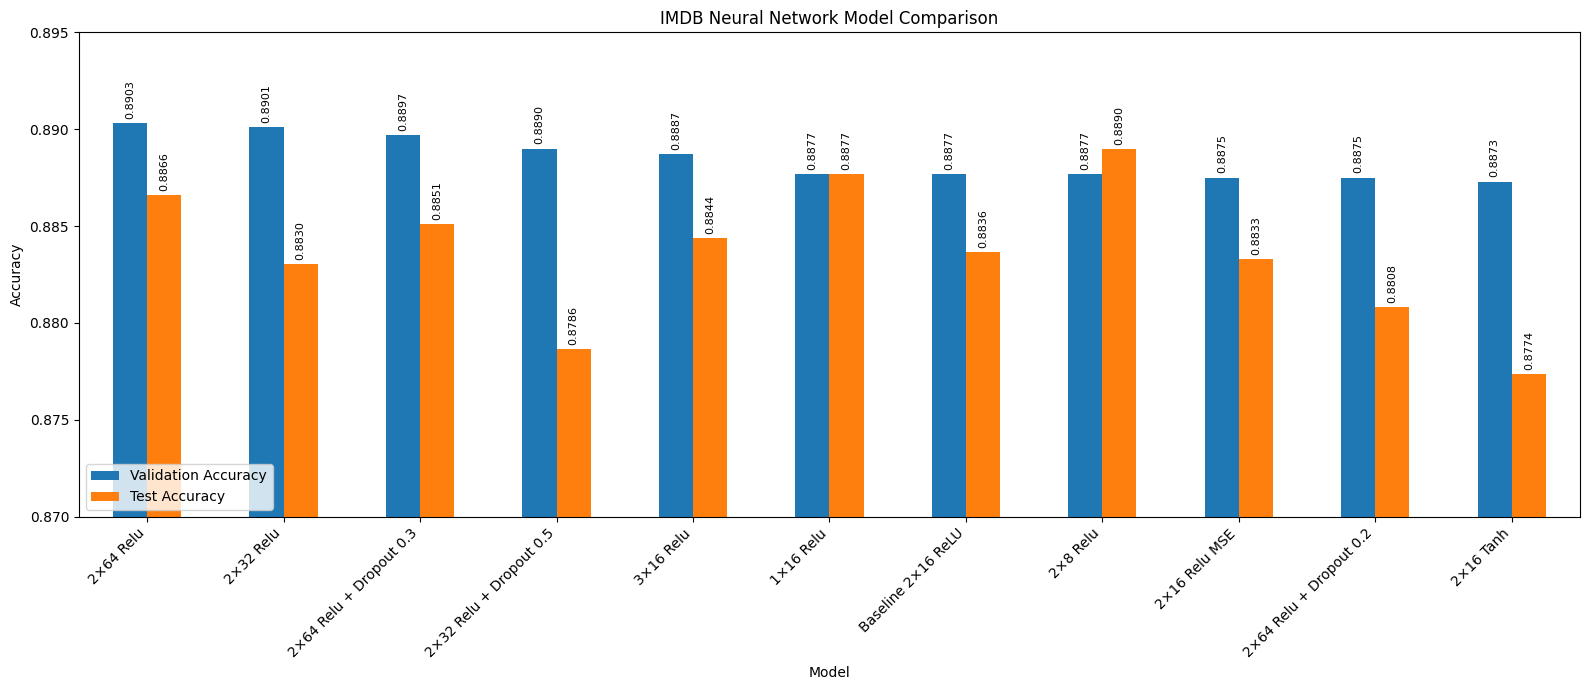

In [87]:
plot_df = results_df.copy()

def make_short_label(row):

    if pd.notna(row["Dropout"]):
        return (
            f'{row["Hidden Layers"]}×{row["Units"]} '
            f'{row["Activation"].capitalize()} '
            f'+ Dropout {row["Dropout"]}'
        )

    if row["Loss"] == "mse":
        return (
            f'{row["Hidden Layers"]}×{row["Units"]} '
            f'{row["Activation"].capitalize()} MSE'
        )

    if row["Activation"] == "tanh":
        return (
            f'{row["Hidden Layers"]}×{row["Units"]} Tanh'
        )

    if (
        row["Hidden Layers"] == 2
        and row["Units"] == 16
        and row["Activation"] == "relu"
        and row["Loss"] == "binary_crossentropy"
    ):
        return "Baseline 2×16 ReLU"

    return (
        f'{row["Hidden Layers"]}×{row["Units"]} '
        f'{row["Activation"].capitalize()}'
    )


plot_df["Short Model"] = plot_df.apply(
    make_short_label,
    axis=1
)

plot_df = plot_df.set_index("Short Model")

ax = plot_df[
    ["Validation Accuracy", "Test Accuracy"]
].plot(
    kind="bar",
    figsize=(16, 7)
)

ax.set_ylim(0.87, 0.895)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Model")
ax.set_title("IMDB Neural Network Model Comparison")

plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower left")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3,
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()

Final Conclusion: The baseline model used two hidden layers with 16 units per layer, ReLU activation, and binary crossentropy loss. Across the experiments, increasing the number of hidden units provided the strongest improvement in validation accuracy, with the 2×64 ReLU model achieving the best validation accuracy of 0.8903 at epoch 3. Changing the number of layers had only a small effect, with one hidden layer performing similarly to the baseline and three hidden layers producing only a slight improvement. Replacing binary crossentropy with MSE slightly reduced performance, and replacing ReLU with tanh reduced test accuracy more noticeably. Dropout was also tested, but none of the dropout models exceeded the validation performance of the best non-dropout model. Based on validation accuracy, the final selected model was the two-hidden-layer, 64-unit, ReLU, binary-crossentropy model without dropout. This model achieved a test accuracy of 0.8866. Among the dropout models, a rate of 0.3 performed best with a validation accuracy of 0.8897, but it still did not exceed the corresponding model without dropout.

In [67]:
results_df.to_csv(
    "imdb_neural_network_results.csv",
    index=False
)